# ENTREGA FINAL - VISUALIZACIÓN OBJETIVO SECUNDARIO OS01
## OS01 – Exposición y experiencia ciudadana en Madrid. 
#### Caracterizar la exposición acústica y su evolución en Madrid, y relacionarla con el uso del espacio público.

### “Caracterizar la exposición acústica y su evolución en Madrid, y relacionarla con el uso del espacio público.”
### Para ello se propone representaciones, análisis y correlaciones que permiten:

* Cuantificar niveles de ruido reales.
* Identificar dónde se genera ruido.
* Estudiar cómo se relaciona con el uso del espacio público (locales, terrazas).
* Analizar condiciones socioeconómicas (renta, calidad de vida).
* Detectar patrones temporales y espaciales.

* INFORMACIÓN SOBRE LOS CÁLCULOS: Para garantizar la eficiencia del análisis y evitar la inclusión de registros de alta frecuencia innecesarios, las visualizaciones temporales del OS01 se construyeron a partir de datos previamente agregados (diarios, semanales y mensuales), manteniendo la capacidad de exploración interactiva sin comprometer el rendimiento del cuaderno.

* PREPRARACIÓN DE ENTORNO

In [1]:
import altair as alt

# Desactivar vegafusion si quedó activado accidentalmente
alt.data_transformers.enable("default", max_rows=None)

# Renderer compatible con JupyterLab / Anaconda
alt.renderers.enable("mimetype")

RendererRegistry.enable('mimetype')

In [2]:
import pandas as pd
import altair as alt
import requests
import reverse_geocoder as rg
import kagglehub
from kagglehub import KaggleDatasetAdapter
from sklearn.decomposition import PCA
from scipy.cluster import hierarchy
from scipy.cluster.hierarchy import fcluster
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import unicodedata



pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

* CARGA DE DATOS PREPROCESADOS

In [3]:
# Carga los datos PREPROCESADOS disponibles en Kaggle. En la cuenta del alumno raquelahdo/ruido-datasets-procesados
# https://www.kaggle.com/datasets/raquelahdo/ruido-datasets-procesados

file_path_01_ruido_diario = "df_01_Ruido_diario_acumulado_processed.csv"
file_path_01_daily = "df_01_daily_processed.csv"
file_path_01_daily_plot = "df_01_daily_plot.csv"
file_path_02_cont_acustica = "df_02_contaminacion_acustica_processed.csv"
file_path_02_estac = "df_02_estacion_processed.csv"
file_path_03_noise_lim = "df_03_noise_limit_processed.csv"
file_path_05_est_ac_proc = "df_05_estaciones-acusticas_processed.csv"
file_path_06_locales = "df_06_locales_terrazas_processed.csv"
# file_path_07_Mad_Q_vida = "df_07_Madrid-calidad-vida_processed.csv"
file_path_07_Q_vida = "df_07_calidad-vida_processed.csv"
# file_path_07_evo_Q_vida = "df_07_evolucion-calidad-vida_processed.csv"
# file_path_07_evo_long_Q_vida = "df_07_evolucion-long-calidad-vida_processed.csv"
# file_path_07_fin_Q_vida_proc = "df_07_final-calidad-vida_processed.csv"
# file_path_09_renta = "df_09_reduced_distribucion-renta_processed.csv"

df_01_ruido_diario = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_01_ruido_diario,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
df_01_daily = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_01_daily,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
df_01_daily_plot = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_01_daily_plot,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
df_02_cont_acustic = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_02_cont_acustica,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
df_02_estac = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_02_estac,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
df_03_noise_lim = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_03_noise_lim,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
df_05_est_ac = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_05_est_ac_proc,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
df_06_locales = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_06_locales,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
# df_07_Mad_Q_vida = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_07_Mad_Q_vida,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
df_07_Q_vida = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_07_Q_vida,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
# df_07_evo_Q_vida = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_07_evo_Q_vida,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
# df_07_evo_long_Q_vida = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_07_evo_long_Q_vida,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
# df_07_fin_Q_vida_proc = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_07_fin_Q_vida_proc,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
# df_09_renta = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_09_renta,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )

In [4]:
df_01_ruido_diario.head()

,NMT,year,month,day,periodo,laeq,l1,l10,l50,l90,l99,fecha,periodo_desc,mes_nombre,year_month,week,month_name
0,3,2014,1,1,D,57.4,66.6,61.1,54.3,49.1,45.0,2014-01-01,Diurno,Enero,2014-01,1,Enero
1,30,2014,1,1,D,55.6,64.7,59.2,51.9,45.9,43.5,2014-01-01,Diurno,Enero,2014-01,1,Enero
2,29,2014,1,1,T,57.2,67.4,62.1,49.0,36.6,29.8,2014-01-01,Total,Enero,2014-01,1,Enero
3,29,2014,1,1,N,55.0,66.7,57.4,41.5,30.9,29.2,2014-01-01,Nocturno,Enero,2014-01,1,Enero
4,29,2014,1,1,E,57.4,67.4,62.5,50.2,41.7,36.7,2014-01-01,Vespertino,Enero,2014-01,1,Enero


In [5]:
df_01_daily.head()

,fecha,periodo,laeq
0,2014-01-01,D,60.644
1,2014-01-01,E,61.176
2,2014-01-01,N,68.928
3,2014-01-01,T,66.156
4,2014-01-02,D,63.608


In [6]:
df_01_daily_plot.head()

,fecha,NMT,laeq
0,2014-01-01,3,61.050
1,2014-01-01,4,70.700
2,2014-01-01,5,64.475
3,2014-01-01,8,68.075
4,2014-01-01,10,64.450


In [7]:
df_02_cont_acustic.head()

,estacion,nombre,year,month,ld,le,ln,laeq,l1,l10,l50,l90,l99,fecha,mes_nombre,year_month,month_name
0,RF-19,Alto de Extremadura,1998,9,NaN,NaN,NaN,63.0,72.4,66.3,59.3,51.4,47.0,1998-09-01,Septiembre,1998-09,Septiembre
1,RF-16,Arturo Soria,1998,9,NaN,NaN,NaN,59.5,67.8,61.6,56.0,45.3,39.1,1998-09-01,Septiembre,1998-09,Septiembre
2,RF-14,Plaza Elíptica,1998,9,NaN,NaN,NaN,67.3,75.3,69.8,64.3,56.7,50.0,1998-09-01,Septiembre,1998-09,Septiembre
3,RF-11,Ramón y Cajal,1998,10,NaN,NaN,NaN,70.3,77.2,72.9,68.8,56.8,46.3,1998-10-01,Octubre,1998-10,Octubre
4,RF-14,Plaza Elíptica,1998,10,NaN,NaN,NaN,68.0,75.8,70.2,64.6,56.8,49.8,1998-10-01,Octubre,1998-10,Octubre


In [8]:
df_02_estac.head()

,estacion,laeq
0,RF-01,67.753311
1,RF-02,68.547328
2,RF-03,62.579321
3,RF-04,65.502980
4,RF-05,61.708411


In [9]:
df_03_noise_lim.head()

,noiselimitreportid_identifier,noisesource,limitvaluedefined,status,areatype,noiselevelindicator,limitvalue,explanation,limitvaluedefined_bool,noiselevel
0,LR_ES_00_01,allsources,yes,inforce,hospital,lday,60.0,This is not a limit value but rather an Acoust...,True,day
1,LR_ES_00_01,allsources,yes,inforce,hospital,levening,60.0,This is not a limit value but rather an Acoust...,True,evening
2,LR_ES_00_01,allsources,yes,inforce,hospital,lnight,50.0,This is not a limit value but rather an Acoust...,True,night
3,LR_ES_00_01,allsources,yes,inforce,school,lday,60.0,This is not a limit value but rather an Acoust...,True,day
4,LR_ES_00_01,allsources,yes,inforce,school,levening,60.0,This is not a limit value but rather an Acoust...,True,evening


In [10]:
df_05_est_ac.head()

,estacion,nombre,ubicacion,distrito,barrio,longitud,latitud,utm_x,utm_y,altitud,fecha_alta
0,RF-01,Paseo de Recoletos,Frente al n23 del Paseo de Recoletos,Centro,Justicia,-3.691877,40.422599,441307,4474893,648,2011-03-07
1,RF-02,Carlos V,"Plaza del Emperador Carlos V, junto al n1 del ...",Retiro,Jerónimos,-3.691509,40.409121,441327,4473397,629,1998-12-01
2,RF-03,Plaza del Carmen,Plaza del Carmen frente al n3 de la Calle de l...,Centro,Sol,-3.703175,40.419251,440346,4474529,657,1999-11-01
3,RF-04,Plaza de España,Frente al n18 de la Plaza de España,Moncloa - Aravaca,Argüelles,-3.712253,40.424005,439580,4475063,637,1998-12-01
4,RF-05,Barrio del Pilar,Parque de La Vaguada semiesquina de Avenida Mo...,Fuencarral - El Pardo,Pilar,-3.711543,40.478197,439688,4481078,673,1999-06-07


In [11]:
df_06_locales.head()

,id_local,rotulo_local,id_terraza,rotulo_terraza,distrito,barrio,cod_barrio_local,seccion_censal,latitud,longitud,superficie_es,superficie_ra,mesas_es,mesas_ra,sillas_es,sillas_ra,desc_periodo_terraza,desc_situacion_terraza,hora_cierre_num,desc_tipo_acceso_local_local,desc_situacion_local_local,cod_postal_local,cod_postal_terraza,fx_carga_local,fx_carga_terraza,longitud_wgs84,latitud_wgs84
0,10000003,VITACA,2038.0,VITACA,CENTRO,JUSTICIA,4.0,1088.0,4475338.53,440554.59,6.48,6.48,2.0,2.0,8.0,8.0,Anual,Abierta,NaN,Puerta Calle,Abierto,28004.0,28004.0,2026-03-05,2026-05-03,-3.700788,40.426558
1,10000004,ZAATAR & CO,19621.0,ZAATAR & CO,CENTRO,UNIVERSIDAD,5.0,1106.0,4475591.53,439945.60,7.02,7.02,3.0,3.0,9.0,9.0,Anual,Abierta,2.0,Puerta Calle,Abierto,28015.0,28015.0,2026-03-05,2026-05-03,-3.707991,40.428794
2,10000013,HOTEL MEDIODIA,NaN,NaN,CENTRO,EMBAJADORES,2.0,1058.0,4473326.52,441199.58,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Puerta Calle,Abierto,28012.0,NaN,2026-03-05,NaN,-3.692999,40.408479
3,10000044,V.M. VINOMANIA,NaN,NaN,CENTRO,PALACIO,1.0,1014.0,4473550.53,439722.59,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Puerta Calle,Cerrado,28005.0,NaN,2026-03-05,NaN,-3.710426,40.410391
4,10000052,MUNE,NaN,NaN,CENTRO,JUSTICIA,4.0,1082.0,4475142.52,440875.59,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Puerta Calle,Abierto,28004.0,NaN,2026-03-05,NaN,-3.696986,40.424816


In [ ]:
# df_07_Mad_Q_vida.head()

In [12]:
df_07_Q_vida.head()

,CCAA,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Total Nacional,100.000000,99.171134,98.761457,99.304088,98.663408,98.225947,97.666577,98.261476,98.552239,99.666386,100.448144,101.048758,100.067925,99.822144,100.187631,99.763378,99.983688
1,Andalucía,98.243355,97.380868,96.050234,95.873410,96.286384,95.622403,93.873830,95.430977,95.109237,97.657589,96.327075,97.800458,97.531583,96.583852,97.405337,96.848018,97.669293
2,Aragón,104.665521,105.104032,104.671560,103.980765,103.854998,101.243728,102.009913,103.563863,103.507154,104.988320,105.015362,105.160684,104.967605,103.561554,104.365009,103.033659,102.971541
3,"Asturias, Principado de",104.694153,104.117801,104.823618,104.799107,104.114874,102.477116,102.114463,101.598634,103.343305,102.808435,103.194704,101.713544,101.577220,102.199418,102.777763,102.421108,103.144408
4,"Balears, Illes",98.671469,97.180334,97.344712,96.118689,96.990238,95.750127,95.020305,95.348632,99.342930,97.257662,100.872675,101.463459,100.802315,98.925490,99.182382,99.454337,100.680923


In [ ]:
# df_07_evo_Q_vida.head()

In [ ]:
# df_07_evo_long_Q_vida.head()

In [ ]:
# df_07_fin_Q_vida_proc.head()

In [ ]:
# df_09_renta.head()

Con el fin de optimizar el rendimiento del cuaderno y evitar el uso innecesario de registros de alta frecuencia, las visualizaciones temporales del OS01 se construyeron a partir de datos previamente agregados (diarios, semanales y mensuales), manteniendo la capacidad de exploración interactiva sin comprometer la interpretabilidad.

## VISUALIZACIÓN 1: Tendencia temporal del ruido (día/tarde/noche) + actividad ciudadana. 
* 
OBJETIVO:
* Cálculo de métricas diarias de actividad ciudadana: Unión ruido + actividad por día
* LAeq, Ld, Le, Ln por día
* Media hora cierre
* Nº terrazas activas
TIPO DE GRÁFICO: Mapa coroplético de barrios 

* DATOS:
* * df_01_daily_plot: ruido diario ya preprocesado
* * df_06_locales_master: actividad ciudadana (hora de cierre y terrazas)


 Se calculan las métricas diarias de actividad ciudadana a partir de df_06_locales_master:
 * media de hora de cierre → actividad nocturna
 * conteo de terrazas activas → presión del espacio público

In [13]:
# Preprocesar ruido diario
df_ruido = df_01_daily.copy()
df_ruido["fecha"] = pd.to_datetime(df_ruido["fecha"])

# Convertimos D/E/N en columnas Ld/Le/Ln
df_ruido_pivot = df_ruido.pivot_table(
    index="fecha",
    columns="periodo",
    values="laeq"
).reset_index()

df_ruido_pivot = df_ruido_pivot.rename(columns={
    "D": "ld",
    "E": "le",
    "N": "ln"
})

# LAeq diario total = media de los 3 periodos
df_ruido_pivot["laeq"] = df_ruido_pivot[["ld","le","ln"]].mean(axis=1)

In [14]:
# Preprocesar actividad ciudadana (df_06 con los locales)
# Queremos obtener: terrazas activas por día y hora de cierre media
df_locales = df_06_locales.copy()

df_locales["fx_carga_local"] = pd.to_datetime(df_locales["fx_carga_local"], errors="coerce")

df_actividad_diaria = (
    df_locales.groupby(df_locales["fx_carga_local"].dt.date)
    .agg(
        terrazas_activas=("id_local", "count"),
        hora_cierre_media=("hora_cierre_num", "mean")
    )
    .reset_index()
    .rename(columns={"fx_carga_local": "fecha"})
)

df_actividad_diaria["fecha"] = pd.to_datetime(df_actividad_diaria["fecha"])


In [15]:
# unimos ruido + actividad
df_os01_1 = df_ruido_pivot.merge(
    df_actividad_diaria,
    on="fecha", how="left"
)

* Para OS01 (tendencia ruido + actividad ciudadana), identificamos:
* * Patrones medios de actividad ciudadana ↔ patrones temporales del ruido.
* * Se calculan actividad por TARDE/NOCHE/SEMANA, NO por fecha exacta de fx_carga_local.

PASO 1 — Creamos el dataset auxiliar de actividad ciudadana MEDIA. Calculamos:  
* * Media de hora de cierre por distrito/barrio
* * Nº de terrazas por zona
* * Actividad global en ciudad
  * 
La información se correlaciona con ruido.

In [16]:
df_actividad = df_06_locales.agg(
    hora_cierre_media=("hora_cierre_num", "mean"),
    terrazas_totales=("id_local", "count")
)

In [17]:
df_actividad.head()

,hora_cierre_num,id_local
hora_cierre_media,14.917341,NaN
terrazas_totales,NaN,203241.0


In [18]:
#VISUALIZACIÓN por código postal

# Asegurar tipos numéricos donde corresponda
df_06_locales["hora_cierre_num"] = pd.to_numeric(df_06_locales["hora_cierre_num"], errors="coerce")

# --- AGRUPACIÓN POR CÓDIGO POSTAL ---

df_actividad_cp = (
    df_06_locales.groupby("cod_postal_local", dropna=True)
    .agg(
        hora_cierre_media=("hora_cierre_num", "mean"),
        num_locales=("id_local", "count"),
        num_terrazas=("id_terraza", "count")
    )
    .reset_index()
)


In [19]:
df_actividad_cp.head()

,cod_postal_local,hora_cierre_media,num_locales,num_terrazas
0,28001.0,15.958068,5467,111
1,28002.0,16.546334,4873,159
2,28003.0,13.965716,4053,190
3,28004.0,13.670949,6274,151
4,28005.0,14.328624,5675,310


In [20]:
# Mapeo de códigos a horas aproximadas
mapa_horas = {12: 23, 13: 24, 14: 1, 15: 2, 16: 3}
df_06_locales["hora_cierre_real"] = df_06_locales["hora_cierre_num"].map(mapa_horas)

# Agregación por CP
df_actividad_cp = (
    df_06_locales.groupby("cod_postal_local", dropna=True)
    .agg(
        hora_cierre_media=("hora_cierre_real", "mean"),
        num_locales=("id_local", "count"),
        num_terrazas=("id_terraza", "count")
    )
    .reset_index()
)

# Agregación por barrio
df_actividad_barrio = (
    df_06_locales.groupby("barrio", dropna=True)
    .agg(
        hora_cierre_media=("hora_cierre_real", "mean"),
        num_locales=("id_local", "count"),
        num_terrazas=("id_terraza", "count")
    )
    .reset_index()
)

In [21]:
df_actividad_barrio.head()

,barrio,hora_cierre_media,num_locales,num_terrazas
0,ABRANTES,1.111111,997,27
1,ACACIAS,1.837838,1519,95
2,ADELFAS,1.090909,616,24
3,AEROPUERTO,1.000000,896,4
4,ALAMEDA DE OSUNA,1.333333,543,22


In [22]:
df_actividad_cp.head()

,cod_postal_local,hora_cierre_media,num_locales,num_terrazas
0,28001.0,2.391304,5467,111
1,28002.0,1.340000,4873,159
2,28003.0,2.857143,4053,190
3,28004.0,1.512821,6274,151
4,28005.0,1.806122,5675,310


* PASO 2: MAPA COROPLÉTICO DE MADRID MOSTRANDO POR CP - HORA DE CIERRE
Se crea un mapa coroplético muestra la actividad nocturna en Madrid a nivel de código postal, utilizando la hora media de cierre como indicador. 
Se usan datos geográficos oficiales del CNIG garantiza la coherencia espacial, mientras que la interactividad permite explorar la relación entre horarios, número de locales y terrazas.

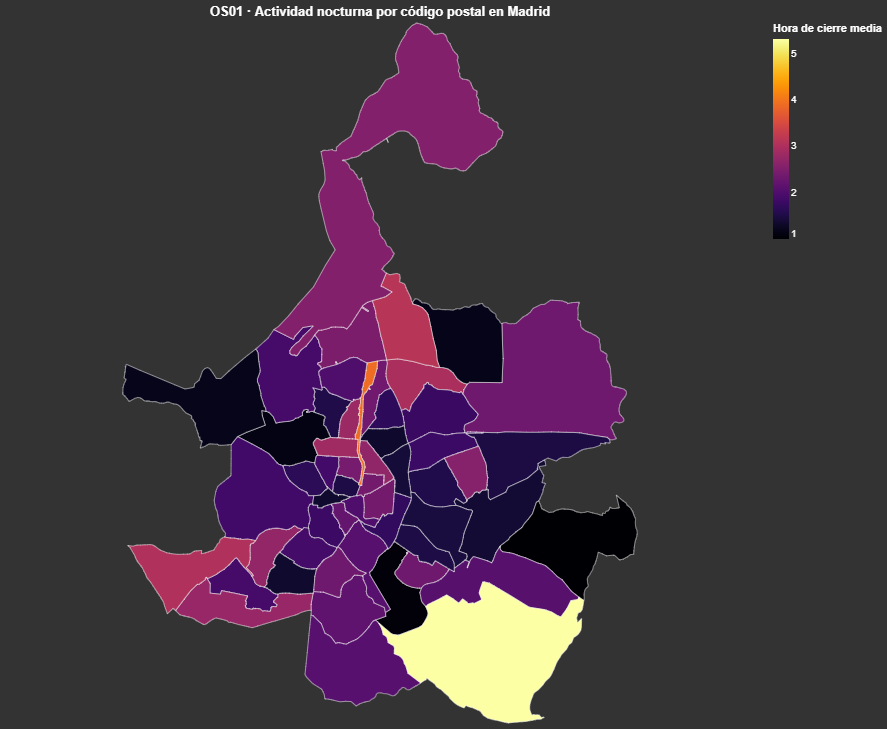

In [23]:
# ---------------------------
# 1. Preparar dataframe CP
# ---------------------------
df_cp = df_actividad_cp.copy()

df_cp["cod_postal_local"] = df_cp["cod_postal_local"].astype(int).astype(str)

# ---------------------------
# 2. URL del GeoJSON (NO se embebe)
# ---------------------------
url_geojson = (
    "https://raw.githubusercontent.com/"
    "inigoflores/ds-codigos-postales/master/data/MADRID.geojson"
)

# ---------------------------
# 3. Mapa coroplético OPTIMIZADO
# ---------------------------
map_cp = (
    alt.Chart(
        alt.Data(url=url_geojson, format=alt.DataFormat(property="features"))
    )
    .mark_geoshape(
        stroke="white",
        strokeWidth=0.5
    )
    .encode(
        color=alt.Color(
            "hora_cierre_media:Q",
            scale=alt.Scale(scheme="inferno"),
            title="Hora de cierre media"
        ),
        tooltip=[
            alt.Tooltip("properties.COD_POSTAL:O", title="Código Postal"),
            alt.Tooltip("hora_cierre_media:Q", title="Hora cierre media", format=".2f"),
            alt.Tooltip("num_locales:Q", title="Nº locales"),
            alt.Tooltip("num_terrazas:Q", title="Nº terrazas"),
        ]
    )
    .transform_lookup(
        lookup="properties.COD_POSTAL",
        from_=alt.LookupData(
            df_cp,
            key="cod_postal_local",
            fields=["hora_cierre_media", "num_locales", "num_terrazas"]
        )
    )
    .project("mercator")
    .properties(
        width=750,
        height=700,
        title="OS01 · Actividad nocturna por código postal en Madrid"
    )
)

map_cp

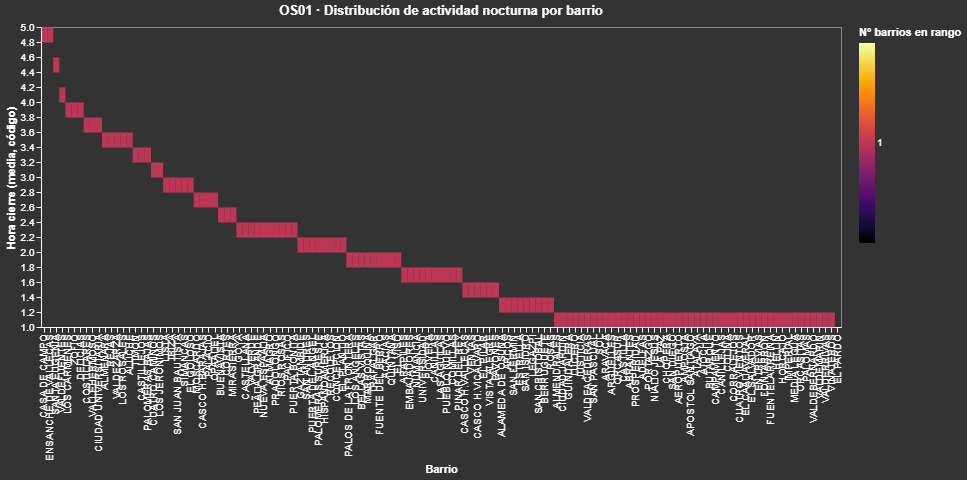

In [24]:
# Mapa de calor por barrio: hora_cierre_media (proxy de actividad nocturna)

chart_horarios_barrio = (
    alt.Chart(df_actividad_barrio)
    .mark_rect()
    .encode(
        x=alt.X("barrio:N", sort="-y", title="Barrio"),
        y=alt.Y("hora_cierre_media:Q", bin=alt.Bin(maxbins=20), title="Hora cierre (media, código)"),
        color=alt.Color("count():Q", title="N° barrios en rango", scale=alt.Scale(scheme="inferno")),
        tooltip=["barrio", "hora_cierre_media"]
    )
    .properties(
        width=800,
        height=300,
        title="OS01 · Distribución de actividad nocturna por barrio"
    )
)
chart_horarios_barrio



### Visualización 2 – Actividad nocturna por barrio

TIPO DE GRÁFICO: Mapa de calor interactivo por barrio y hora de cierre.

HIPÓTESIS: Barrios con horarios de cierre más tardíos concentran mayor presión nocturna.


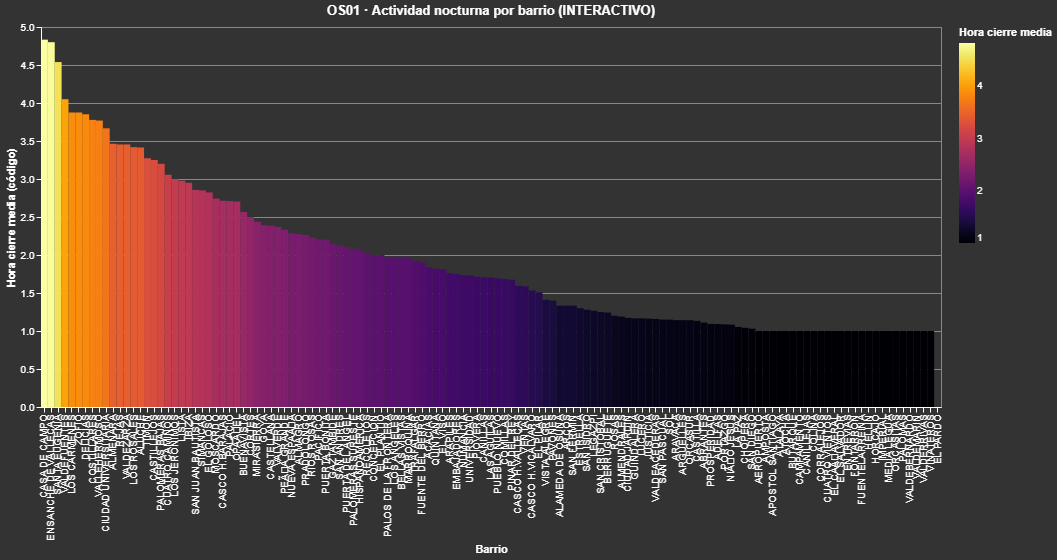

In [25]:
# Selector interactivo por barrio
select_barrio = alt.selection_point(fields=["barrio"], on="click")
hover = alt.selection_point(fields=["barrio"], on="mouseover")

chart_horarios_barrio = (
    alt.Chart(df_actividad_barrio)
    .mark_rect()
    .encode(
        x=alt.X("barrio:N", sort="-y", title="Barrio"),
        y=alt.Y("hora_cierre_media:Q", title="Hora cierre media (código)"),

        color=alt.condition(
            select_barrio | hover,
            alt.Color("hora_cierre_media:Q", scale=alt.Scale(scheme="inferno"), title="Hora cierre media"),
            alt.value("lightgray")
        ),

        opacity=alt.condition(select_barrio | hover, alt.value(1), alt.value(0.4)),

        tooltip=[
            alt.Tooltip("barrio:N", title="Barrio"),
            alt.Tooltip("hora_cierre_media:Q", title="Hora cierre media (código)"),
            alt.Tooltip("num_locales:Q", title="Locales"),
            alt.Tooltip("num_terrazas:Q", title="Terrazas")
        ]
    )
    .add_params(select_barrio, hover)
    .properties(
        width=900,
        height=380,
        title="OS01 · Actividad nocturna por barrio (INTERACTIVO)"
    )
    .interactive()   # Zoom + pan
)

chart_horarios_barrio

### Visualización 3 – Evolución temporal del ruido

TIPO DE GRÁFICOS: 
* Línea temporal de laeq
* Comparación D / E / N
* Picos semanales o estacionales

HIPÓTESIS: El ruido nocturno presenta comportamientos distintos al diurno y está vinculado a patrones de uso urbano, no solo al tráfico.  

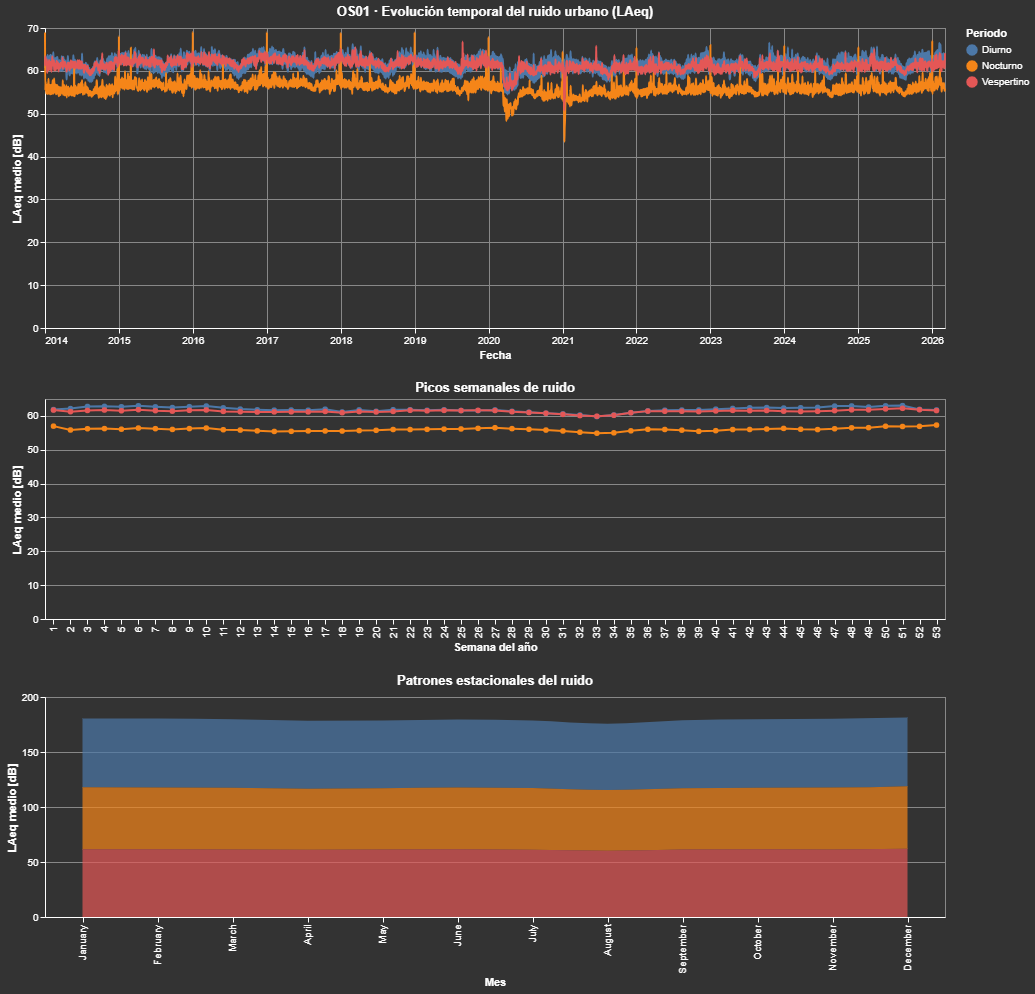

In [26]:
# ================================
# VISUALIZACIÓN 1 – EVOLUCIÓN TEMPORAL DEL RUIDO
# Altair interactivo (LAeq por periodos D/E/N)
# ================================

# ----------------------------------------------------------
# 1. Usamos tu dataframe real df_01_ruido_diario
# ----------------------------------------------------------

df = df_01_ruido_diario.copy()

# Asegurar formato fecha
df['fecha'] = pd.to_datetime(df['fecha'])

# Mapeo de periodos

df["periodo_desc"] = df["periodo"].map({
    "D": "Diurno",
    "E": "Vespertino",
    "N": "Nocturno"
})

# Filtrar solo D/E/N (comparación solicitada)
df = df[df["periodo"].isin(["D", "E", "N"])]


# ---------- AGREGACIONES ----------
df_daily = (
    df
    .groupby(["fecha", "periodo_desc"], as_index=False)
    .agg(laeq_medio=("laeq", "mean"))
)

df_daily["week"] = df_daily["fecha"].dt.isocalendar().week.astype(int)
df_daily["month"] = df_daily["fecha"].dt.month
df_daily["month_name"] = df_daily["fecha"].dt.month_name()

df_week = (
    df_daily
    .groupby(["week", "periodo_desc"], as_index=False)
    .agg(laeq_medio=("laeq_medio", "mean"))
)

df_month = (
    df_daily
    .groupby(["month", "month_name", "periodo_desc"], as_index=False)
    .agg(laeq_medio=("laeq_medio", "mean"))
)


# ----------------------------------------------------------
# 2. Selectores interactivos
# ----------------------------------------------------------

# Selección temporal con brush (sobre el eje X)
brush_time = alt.selection_interval(encodings=['x'], name='SeleccionTemporal')

# Selección multiserie por leyenda
select_period = alt.selection_point(fields=['periodo_desc'], bind='legend', name='Periodo')


# ----------------------------------------------------------
# 3. Gráfico principal – Evolución temporal LAeq (D/E/N)
# ----------------------------------------------------------


chart_line = (
    alt.Chart(df_daily)
    .mark_line(interpolate="monotone")
    .encode(
        x=alt.X("fecha:T", title="Fecha"),
        y=alt.Y("laeq_medio:Q", title="LAeq medio [dB]"),
        color=alt.Color("periodo_desc:N", title="Periodo"),
        tooltip=[
            alt.Tooltip("yearmonthdate(fecha):T", title="Fecha"),
            alt.Tooltip("laeq_medio:Q", title="LAeq medio", format=".2f"),
            alt.Tooltip("periodo_desc:N", title="Periodo")
        ]
    )
    .add_params(select_period, brush_time)
    .transform_filter(select_period)
    .properties(
        width=900,
        height=300,
        title="OS01 · Evolución temporal del ruido urbano (LAeq)"
    )
)



# ----------------------------------------------------------
# 4. Picos semanales – Promedio por semana
# ----------------------------------------------------------

chart_week = (
    alt.Chart(df_week)
    .mark_line(point=True)
    .encode(
        x=alt.X("week:O", title="Semana del año"),
        y=alt.Y("laeq_medio:Q", title="LAeq medio [dB]"),
        color=alt.Color("periodo_desc:N", title="Periodo"),
        tooltip=[
            alt.Tooltip("week:O", title="Semana"),
            alt.Tooltip("laeq_medio:Q", title="LAeq medio", format=".2f"),
            alt.Tooltip("periodo_desc:N", title="Periodo")
        ]
    )
    .transform_filter(brush_time)
    .properties(
        width=900,
        height=220,
        title="Picos semanales de ruido"
    )
)


# ----------------------------------------------------------
# 5. Picos estacionales – Promedio por mes
# ----------------------------------------------------------


chart_month = (
    alt.Chart(df_month)
    .mark_area(opacity=0.7, interpolate="monotone")
    .encode(
        x=alt.X(
            "month_name:N",
            sort=[
                "January", "February", "March", "April", "May", "June",
                "July", "August", "September", "October", "November", "December"
            ],
            title="Mes"
        ),
        y=alt.Y("laeq_medio:Q", title="LAeq medio [dB]"),
        color=alt.Color("periodo_desc:N", title="Periodo"),
        tooltip=[
            alt.Tooltip("month_name:N", title="Mes"),
            alt.Tooltip("laeq_medio:Q", title="LAeq medio", format=".2f"),
            alt.Tooltip("periodo_desc:N", title="Periodo")
        ]
    )
    .transform_filter(brush_time)
    .properties(
        width=900,
        height=220,
        title="Patrones estacionales del ruido"
    )
)


# ----------------------------------------------------------
# 6. Dashboard final (vistas coordinadas)
# ----------------------------------------------------------

final_chart = alt.vconcat(
    chart_line,
    chart_week,
    chart_month
).resolve_scale(color='shared')

final_chart

### Visualización 4 – Ruido NOCTURNO + actividad urbana
OBJETIVO: Correlacionar el ruido noctuurno (obtenido del laeq nocturno) con la actividad urbana (entendida como hora_cierre_media de los locales)
Y comparar las medidas por barrios.

TIPO DE GRÁFICO: Scatter plot o small multiples

Hipótesis: La intensidad nocturna del ocio presenta correlación con niveles acústicos elevados.

Enfoque metodológico del gráfico:

* Unidad de análisis: barrio
* Variable X: hora_cierre_media (aproximación de intensidad nocturna del ocio)
* Variable Y: Ln (ruido ambiental nocturno)
* Tamaño del punto: nº de locales 
* Color: barrio (o densidad de locales)
* Datos pre‑agregados por barrio para reducir el volumen de datos en el notebook

In [27]:
df_06_locales.head()

,id_local,rotulo_local,id_terraza,rotulo_terraza,distrito,barrio,cod_barrio_local,seccion_censal,latitud,longitud,superficie_es,superficie_ra,mesas_es,mesas_ra,sillas_es,sillas_ra,desc_periodo_terraza,desc_situacion_terraza,hora_cierre_num,desc_tipo_acceso_local_local,desc_situacion_local_local,cod_postal_local,cod_postal_terraza,fx_carga_local,fx_carga_terraza,longitud_wgs84,latitud_wgs84,hora_cierre_real
0,10000003,VITACA,2038.0,VITACA,CENTRO,JUSTICIA,4.0,1088.0,4475338.53,440554.59,6.48,6.48,2.0,2.0,8.0,8.0,Anual,Abierta,NaN,Puerta Calle,Abierto,28004.0,28004.0,2026-03-05,2026-05-03,-3.700788,40.426558,NaN
1,10000004,ZAATAR & CO,19621.0,ZAATAR & CO,CENTRO,UNIVERSIDAD,5.0,1106.0,4475591.53,439945.60,7.02,7.02,3.0,3.0,9.0,9.0,Anual,Abierta,2.0,Puerta Calle,Abierto,28015.0,28015.0,2026-03-05,2026-05-03,-3.707991,40.428794,NaN
2,10000013,HOTEL MEDIODIA,NaN,NaN,CENTRO,EMBAJADORES,2.0,1058.0,4473326.52,441199.58,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Puerta Calle,Abierto,28012.0,NaN,2026-03-05,NaN,-3.692999,40.408479,NaN
3,10000044,V.M. VINOMANIA,NaN,NaN,CENTRO,PALACIO,1.0,1014.0,4473550.53,439722.59,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Puerta Calle,Cerrado,28005.0,NaN,2026-03-05,NaN,-3.710426,40.410391,NaN
4,10000052,MUNE,NaN,NaN,CENTRO,JUSTICIA,4.0,1082.0,4475142.52,440875.59,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Puerta Calle,Abierto,28004.0,NaN,2026-03-05,NaN,-3.696986,40.424816,NaN


id_terraza es el único indicador consistente de existencia de terraza.
* Se cuentan terrazas por barrio.
* Se alinea con “actividad nocturna exterior”.

Refuerza la hipótesis ruido–ocio
Evita errores por NaNs estructurales de mesas/sillas.

El número de terrazas por barrio se estimó a partir del identificador de terraza presente en el dataset de locales, contabilizando aquellas observaciones con terraza asociada. Esta aproximación permite medir la intensidad del ocio exterior de forma consistente, evitando problemas derivados de información incompleta sobre mesas o sillas.

El ruido nocturno se caracterizó a partir del indicador Ln, asociado a cada estación acústica. 
La asignación espacial a barrios se realizó mediante la vinculación de cada estación con su barrio correspondiente, permitiendo obtener un nivel medio de ruido nocturno a escala de barrio.

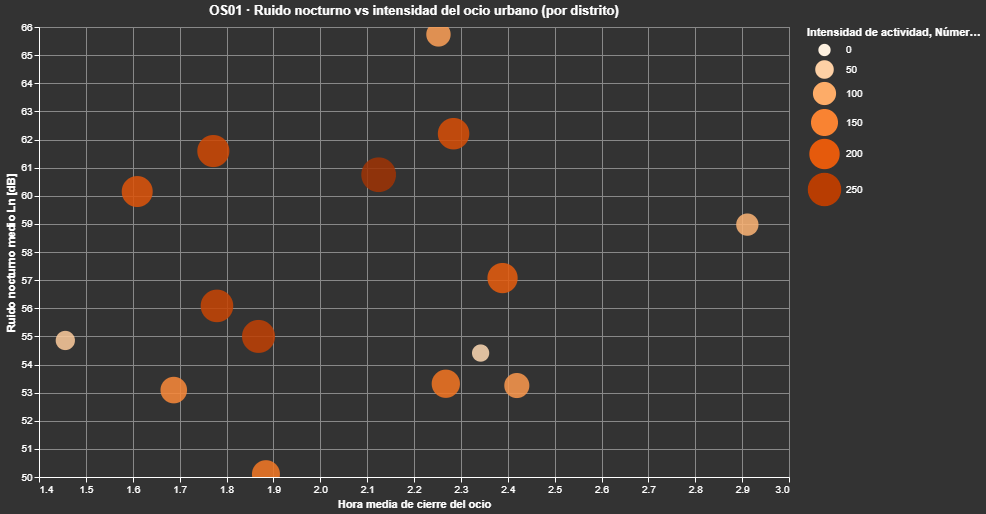

In [29]:
# =========================================================
# OS01 · VISUALIZACIÓN 4
# Ruido nocturno vs intensidad del ocio (POR DISTRITO)
# =========================================================

# ---------------------------------------------------------
# 0. Función de normalización de texto (CLAVE)
# ---------------------------------------------------------
def normaliza_texto(s):
    if pd.isna(s):
        return s
    s = unicodedata.normalize("NFKD", s)
    s = "".join(c for c in s if not unicodedata.combining(c))
    return s.upper().strip()

# =========================================================
# 1. ACTIVIDAD URBANA NOCTURNA → DISTRITO
# =========================================================

df_act = df_06_locales.copy()

# Mapeo correcto de hora de cierre
mapa_horas = {12: 23, 13: 24, 14: 1, 15: 2, 16: 3}

df_act = df_act[df_act["hora_cierre_num"].isin(mapa_horas)]
df_act["hora_cierre_real"] = df_act["hora_cierre_num"].map(mapa_horas)

# Agregado por distrito
df_actividad_distrito = (
    df_act
    .groupby("distrito", as_index=False)
    .agg(
        hora_cierre_media=("hora_cierre_real", "mean"),
        num_locales=("id_local", "nunique"),
        num_terrazas=("id_terraza", lambda x: x.notna().sum())
    )
)

df_actividad_distrito["distrito_norm"] = df_actividad_distrito["distrito"].apply(normaliza_texto)

# =========================================================
# 2. RUIDO NOCTURNO (Ln) → DISTRITO
# =========================================================

df_ruido = df_02_cont_acustic.copy()

# Ruido nocturno: Ln ≠ NaN
df_ruido = df_ruido[df_ruido["ln"].notna()]

# Añadir distrito desde estaciones
df_ruido = df_ruido.merge(
    df_05_est_ac[["estacion", "distrito"]],
    on="estacion",
    how="left"
)

# Agregado por distrito
df_ruido_distrito = (
    df_ruido
    .groupby("distrito", as_index=False)
    .agg(
        laeq_nocturno=("ln", "mean")
    )
)

df_ruido_distrito["distrito_norm"] = df_ruido_distrito["distrito"].apply(normaliza_texto)

# =========================================================
# 3. DATASET FINAL INTEGRADO (ROBUSTO)
# =========================================================

df_corr_distrito = (
    df_actividad_distrito
    .merge(
        df_ruido_distrito,
        on="distrito_norm",
        how="inner",
        suffixes=("_act", "_ruido")
    )
)

# =========================================================
# 4. SCATTER FINAL
# =========================================================

scatter_nocturno = (
    alt.Chart(df_corr_distrito)
    .mark_circle(opacity=0.85)
    .encode(
        x=alt.X(
            "hora_cierre_media:Q",
            title="Hora media de cierre del ocio",
            scale=alt.Scale(zero=False)
        ),
        y=alt.Y(
            "laeq_nocturno:Q",
            title="Ruido nocturno medio Ln [dB]",
            scale=alt.Scale(zero=False)
        ),
        size=alt.Size(
            "num_locales:Q",
            title="Número de locales",
            scale=alt.Scale(range=[150, 1200])
        ),
        color=alt.Color(
            "num_locales:Q",
            title="Intensidad de actividad",
            scale=alt.Scale(scheme="oranges")
        ),
        tooltip=[
            alt.Tooltip("distrito_act:N", title="Distrito"),
            alt.Tooltip("hora_cierre_media:Q", format=".2f"),
            alt.Tooltip("laeq_nocturno:Q", format=".1f"),
            alt.Tooltip("num_locales:Q", title="Locales"),
            alt.Tooltip("num_terrazas:Q", title="Terrazas")
        ]
    )
    .interactive()
    .properties(
        width=750,
        height=450,
        title="OS01 · Ruido nocturno vs intensidad del ocio urbano (por distrito)"
    )
)

scatter_nocturno

La correlación entre actividad nocturna y ruido se analiza a nivel de distrito, dado que las estaciones acústicas no se corresponden de forma unívoca con los límites administrativos de barrio. Para garantizar la coherencia espacial entre fuentes, se realizó una normalización previa de los nombres de distrito y se agregaron los indicadores antes de su integración.

### Visualización 5 – Ruido y calidad de vida (alto nivel)
El ruido es un factor ambiental que influye indirectamente en la percepción de calidad de vida urbana.
* OBJETIVO: Se busca correspondencia temporal y contexto.

Para la representación se utiliza:  
* Evolución de calidad de vida en Madrid.
* Comparativa con ruido a lo largo de los años.

Escala: ciudad de Madrid (no intraurbana)
Unidad temporal: año
DATOS:
* Ruido → LAeq medio anual (exposición acústica)
* Calidad de vida → índice agregado / percepción media



TIPO DE GRÁFICO: Gráfico combinado de líneas (dual‑axis, conceptualmente) interactivo
* Línea 1: Evolución del ruido medio anual
* Línea 2: Evolución del índice de calidad de vida
Ambas sobre el mismo eje temporal

En Altair se utilizan: líneas superpuestas, paneles sincronizados y capas con escalas independientes claramente etiquetadas

🔴 Línea roja → Ruido medio anual [dB]
🔵 Línea azul → Índice de calidad de vida

* La Visualización 5 muestra de forma conjunta la evolución del ruido urbano y la percepción agregada de la calidad de vida. 
* La línea roja representa el nivel medio anual de ruido, mientras que la línea azul corresponde al índice de calidad de vida.
* La comparación temporal permite contextualizar el ruido como un factor ambiental que influye indirectamente en la experiencia urbana y el bienestar percibido.

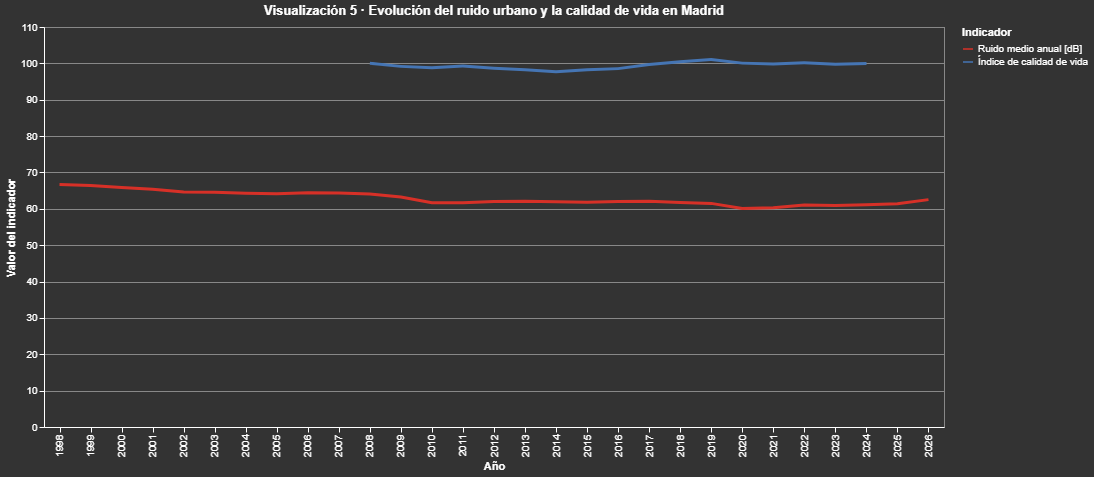

In [30]:
# =========================================================
# VISUALIZACIÓN 5 · RUIDO y CALIDAD DE VIDA (ALTO NIVEL)
# =========================================================

# ---------------------------------------------------------
# 1. RUIDO MEDIO ANUAL (Madrid)
# ---------------------------------------------------------
df_ruido_anual = (
    df_02_cont_acustic
    .dropna(subset=["laeq"])
    .groupby("year", as_index=False)
    .agg(
        ruido_medio=("laeq", "mean")
    )
)

df_ruido_anual["Indicador"] = "Ruido medio anual [dB]"
df_ruido_anual = df_ruido_anual.rename(columns={"ruido_medio": "valor"})

# ---------------------------------------------------------
# 2. CALIDAD DE VIDA (Madrid / Total Nacional)
# ---------------------------------------------------------
df_calidad_vida = (
    df_07_Q_vida
    .query("CCAA == 'Total Nacional'")   # usar 'Madrid' si existe
    .drop(columns=["CCAA"])
    .melt(var_name="year", value_name="valor")
)

df_calidad_vida["year"] = df_calidad_vida["year"].astype(int)
df_calidad_vida["Indicador"] = "Índice de calidad de vida"

# ---------------------------------------------------------
# 3. DATASET COMBINADO (FORMATO LARGO)
# ---------------------------------------------------------
df_ruido_calidad_long = pd.concat(
    [df_ruido_anual[["year", "valor", "Indicador"]],
     df_calidad_vida[["year", "valor", "Indicador"]]],
    ignore_index=True
)

# ---------------------------------------------------------
# 4. VISUALIZACIÓN FINAL CON LEYENDA + INTERACTIVIDAD
# ---------------------------------------------------------
visualizacion_5 = (
    alt.Chart(df_ruido_calidad_long)
    .mark_line(strokeWidth=3)
    .encode(
        x=alt.X("year:O", title="Año"),
        y=alt.Y("valor:Q", title="Valor del indicador"),
        color=alt.Color(
            "Indicador:N",
            title="Indicador",
            scale=alt.Scale(
                domain=[
                    "Ruido medio anual [dB]",
                    "Índice de calidad de vida"
                ],
                range=["#d73027", "#4575b4"]  # rojo / azul
            )
        ),
        tooltip=[
            alt.Tooltip("year:O", title="Año"),
            alt.Tooltip("Indicador:N", title="Indicador"),
            alt.Tooltip("valor:Q", title="Valor", format=".2f")
        ]
    )
    .interactive()   # ✅ INTERACTIVIDAD AÑADIDA
    .properties(
        width=900,
        height=400,
        title="Visualización 5 · Evolución del ruido urbano y la calidad de vida en Madrid"
    )
)

visualizacion_5

In [31]:
%whos

Variable                     Type            Data/Info
------------------------------------------------------
KaggleDatasetAdapter         EnumType        <enum 'KaggleDatasetAdapter'>
PCA                          ABCMeta         <class 'sklearn.decomposition._pca.PCA'>
StandardScaler               type            <class 'sklearn.preproces<...>ng._data.StandardScaler'>
alt                          module          <module 'altair' from 'C:<...>es\\altair\\__init__.py'>
brush_time                   Parameter       Parameter('SeleccionTempo<...>pe: 'interval'\n  })\n}))
chart_horarios_barrio        Chart           alt.Chart(...)
chart_line                   Chart           alt.Chart(...)
chart_month                  Chart           alt.Chart(...)
chart_week                   Chart           alt.Chart(...)
dataframe_columns            function        <function dataframe_colum<...>ns at 0x00000232A4AAF600>
dataframe_hash               function        <function dataframe_hash at 0x00000232AD